In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv") #----- 자기 경로 설정!!
df_cleaned = pd.read_csv("first_clean_data.csv")

In [2]:
# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
df_machine = df_cleaned.copy()
df_machine.head()

,Unnamed: 0,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197


In [4]:
drop_cols = ['name', 'description', 'neighbourhood_cleansed', 'number_of_reviews',
            'estimated_revenue_l365d','calculated_host_listings_count_shared_rooms',
            'calculated_host_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms','host_id','host_since','id','latitude',
            'longitude','amenities','property_type','Unnamed: 0','number_of_reviews_ltm','availability_365','beds','bedrooms','accommodates','room_type','neighbourhood_group_cleansed',
            'host_is_superhost','host_acceptance_rate','estimated_occupancy_l365d','log_price']#'host_response_time','host_response_rate','reviews_per_month','price'
df_machine=df_machine.drop(columns = drop_cols)

In [5]:
df_machine.info()

<class 'pandas.DataFrame'>
RangeIndex: 22248 entries, 0 to 22247
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_time           22248 non-null  float64
 1   host_response_rate           22248 non-null  float64
 2   price                        22248 non-null  int64  
 3   review_scores_rating         15486 non-null  float64
 4   review_scores_accuracy       15486 non-null  float64
 5   review_scores_cleanliness    15486 non-null  float64
 6   review_scores_checkin        15486 non-null  float64
 7   review_scores_communication  15486 non-null  float64
 8   review_scores_location       15486 non-null  float64
 9   review_scores_value          15486 non-null  float64
 10  reviews_per_month            15486 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 1.9 MB


In [6]:
df_machine = df_machine.dropna(subset = ['review_scores_rating'])

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df_machine.drop(columns=["review_scores_rating"])
y = df_machine["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import RobustScaler

X_train['price'] = np.log1p(X_train['price'])
X_test['price'] = np.log1p(X_test['price'])

scale_cols = ['host_response_rate','reviews_per_month','price']
scale_cols = [c for c in scale_cols if c in X_train.columns]  # 안전장치

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

X_train[scale_cols].describe()

,host_response_rate,reviews_per_month,price
count,12388.000000,12388.000000,12388.000000
mean,-0.967759,0.497283,0.028649
std,1.630515,1.559489,0.785338
min,-4.040000,-0.371212,-2.134796
25%,-1.000000,-0.242424,-0.504075
50%,0.000000,0.000000,0.000000
75%,0.000000,0.757576,0.495925
max,0.000000,47.333333,4.969887


In [9]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LightGBM 회귀 모델 생성 및 하이퍼파라미터 세팅
lgbm_model = LGBMRegressor(
    n_estimators=100,      # 나무의 개수
    learning_rate=0.1,     # 학습률 (오답 수정 강도)
    num_leaves=31,         # 하나의 나무가 가질 수 있는 최대 잎(노드)의 개수
    random_state=42,       # 결과 고정
    n_jobs=-1                        # 모든 CPU 코어 사용
)

In [10]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1273
[LightGBM] [Info] Number of data points in the train set: 12388, number of used features: 10
[LightGBM] [Info] Start training from score 4.723013


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
# 평가 데이터로 예측 수행
y_pred_lgbm = lgbm_model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
# 실제 정답(y_test)과 모델이 적어낸 답(y_pred)을 비교하여 오차 계산
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("=== LightGBM 예측 결과 ===")
print(f"MAE (평균 절대 오차): {mae_lgbm:.4f}")
print(f"RMSE (평균 제곱근 오차): {rmse_lgbm:.4f}")
print(f"R2 Score (결정계수): {r2_lgbm:.4f}")

=== LightGBM 예측 결과 ===
MAE (평균 절대 오차): 0.0831
RMSE (평균 제곱근 오차): 0.1676
R2 Score (결정계수): 0.8523


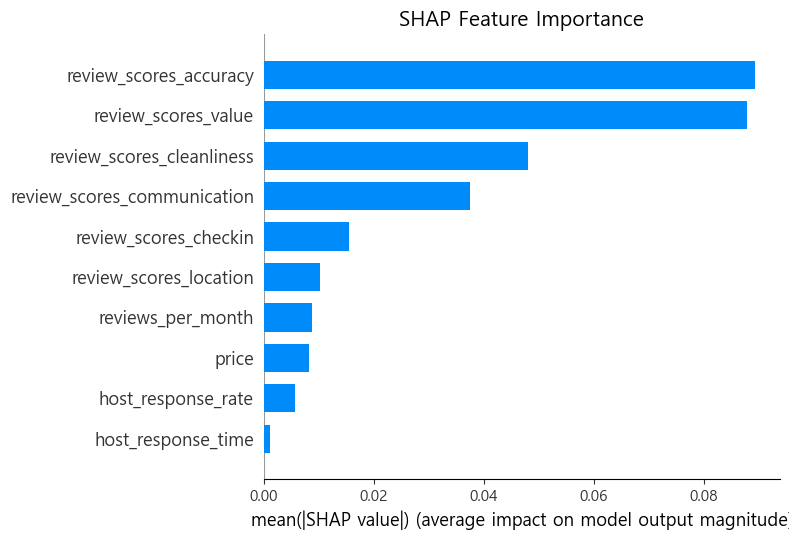

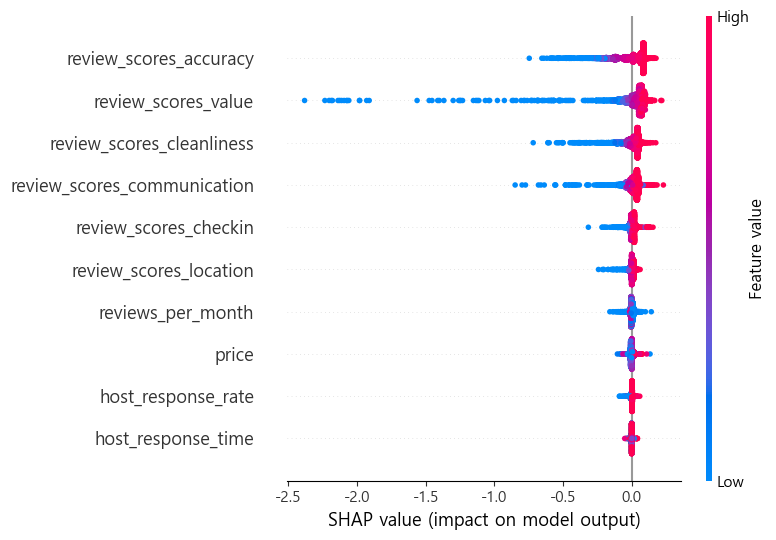

In [14]:
import shap
# 모델이 학습한 데이터의 특성을 바탕으로 기여도를 계산.
explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

plt.title('SHAP Feature Importance', fontsize=15)
plt.tight_layout()
plt.show()

# (빨간색: 높은 값, 파란색: 낮은 값)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test)

In [15]:
# 신규 호스트 가상 데이터 (딕셔너리)
my_listing = {
    'price': 500, 
    'review_scores_value': 4.8,
    'review_scores_cleanliness': 4.9,
    'review_scores_communication': 4.8,
    'review_scores_accuracy': 4.9,
    'review_scores_checkin': 4.8,
    'review_scores_location': 4.8,
    'host_response_rate': 95,
    'reivews_per_month' : 300,
    'host_response_time': 1
}

# 예측 함수
def predict_with_refined_model(input_data):
    test_df = pd.DataFrame([input_data])
    
    # 로그 변환
    if 'price' in test_df.columns:
        test_df['price'] = np.log1p(test_df['price'])
    
    # 원-핫 인코딩 및 컬럼 맞추기 : X_train 컬럼들을 0으로 초기화한 뒤 매핑
    final_input = pd.DataFrame(0, index=[0], columns=X_train.columns)
    
    for col, value in test_df.iloc[0].items():
        if col in final_input.columns:
            final_input[col] = value
        else:
            combined_col = f"{col}_{value}"
            if combined_col in final_input.columns:
                final_input[combined_col] = 1
    
    # final_scale_target 리스트를 재사용
    final_input[scale_cols] = scaler.transform(final_input[scale_cols])
    
    # 예측
    prediction = lgbm_model.predict(final_input)[0]
    return prediction

# 결과 출력
score = predict_with_refined_model(my_listing)
print(f"예상 평점: {score:.2f}")

예상 평점: 4.80


In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# 1. 모든 피처에 대한 위젯 생성 (학습 데이터 기준)
style = {'description_width': '150px'} # 가독성을 위해 설명 너비 조절

# 수치형 변수 슬라이더
price_slider = widgets.IntSlider(value=150, min=10, max=500, step=5, description='가격 ($)', style=style)
rpm_slider = widgets.FloatSlider(value=2.0, min=0, max=50.0, step=0.1, description='월평균 리뷰수', style=style)
resp_rate_slider = widgets.IntSlider(value=100, min=0, max=100, step=1, description='호스트 응답률 (%)', style=style)

# 리뷰 세부 점수 (보통 평점 예측의 핵심 피처들)
val_slider = widgets.FloatSlider(value=4.8, min=0, max=5.0, step=0.1, description='가성비 점수', style=style)
cln_slider = widgets.FloatSlider(value=4.8, min=0, max=5.0, step=0.1, description='청결도 점수', style=style)
com_slider = widgets.FloatSlider(value=4.8, min=0, max=5.0, step=0.1, description='소통 점수', style=style)
acc_slider = widgets.FloatSlider(value=4.8, min=0, max=5.0, step=0.1, description='정확도 점수', style=style)
chk_slider = widgets.FloatSlider(value=4.8, min=0, max=5.0, step=0.1, description='체크인 점수', style=style)
loc_slider = widgets.FloatSlider(value=4.8, min=0, max=5.0, step=0.1, description='위치 점수', style=style)

# 2. 실시간 업데이트 함수
output = widgets.Output()

def update_prediction(change):
    with output:
        clear_output(wait=True)
        
        # [핵심] 딕셔너리에 학습에 쓰인 모든 키값을 정확히 매칭
        current_listing = {
            'price': price_slider.value,
            'reviews_per_month': rpm_slider.value,
            'host_response_rate': resp_rate_slider.value,
            'review_scores_value': val_slider.value,
            'review_scores_cleanliness': cln_slider.value,
            'review_scores_communication': com_slider.value,
            'review_scores_accuracy': acc_slider.value,
            'review_scores_checkin': chk_slider.value,
            'review_scores_location': loc_slider.value,
            # 만약 host_response_time 같은 범주형이 있다면 기본값이나 위젯 추가 필요
            'host_response_time': 1 
        }
        
        # 예측 수행
        try:
            pred_score = predict_with_refined_model(current_listing)
            
            # 시각적 피드백
            print(f"✅ 실시간 예상 평점: {pred_score:.3f} / 5.0")
            
            # 점수 바 차트 시각화
            fig, ax = plt.subplots(figsize=(7, 1.5))
            color = '#2ECC71' if pred_score >= 4.7 else '#F1C40F' if pred_score >= 4.4 else '#E74C3C'
            ax.barh(['Rating'], [pred_score], color=color)
            ax.set_xlim(0, 5)
            ax.axvline(x=4.5, color='black', linestyle='--', alpha=0.3) # 기준선
            plt.title("Current Listing Performance Estimate")
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"❌ 오류 발생: {e}")
            print("Tip: predict_with_refined_model 함수 내부의 컬럼명과 딕셔너리 키값이 일치하는지 확인하세요.")

# 3. 이벤트 연결 (모든 위젯에 관찰자 등록)
all_widgets = [price_slider, rpm_slider, resp_rate_slider, val_slider, 
               cln_slider, com_slider, acc_slider, chk_slider, loc_slider]

for w in all_widgets:
    w.observe(update_prediction, names='value')

# 4. 레이아웃 배치 (좌측 입력, 우측 결과)
input_ui = widgets.VBox([
    widgets.HTML("<b style='font-size:15px;'>💰 기본 정보</b>"),
    price_slider, rpm_slider, resp_rate_slider,
    widgets.HTML("<br><b style='font-size:15px;'>⭐ 상세 만족도 지표</b>"),
    val_slider, cln_slider, com_slider, acc_slider, chk_slider, loc_slider
])

display(widgets.HBox([input_ui, output], layout=widgets.Layout(gap='50px')))

# 초기 실행
update_prediction(None)